In [10]:
# HI 2022 Term Project
# Title: Heart Disease
# Instructor: Ahmed Tafti
# Team: Isabella, Coleen, Tarique
import pandas  as pd
import numpy as np
from matplotlib import pyplot as plt
from sklearn.model_selection import KFold,cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report
import seaborn as sns



In [5]:
# STEP 2: EXPLORING THE DATASET
#Load the heart dataset
ds = pd.read_csv("heart.csv")
print(ds)

#Dataset size/length
len(ds)

#Dataset shape
print(ds.shape)

#Display the size and shape of the dataset
dataset_info = {"Number of Rows":1025,
                "Number of Columns": 14,
                "Column Names": ds.columns.tolist(),
                "Data Types": ds.dtypes,
                "Number of Missing Values": ds.isnull().sum().sum()} # Use ds for missing values

print(dataset_info)

# Checking for missing values
print ("Missing values in each Columns:")
print(ds.isnull().sum())

# Understanding the Data
print("Data Types of Each Column:")
print(ds.dtypes)

# Summary Statistics
print("Summary Statistics:")
print(ds.describe())

      age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
0      52    1   0       125   212    0        1      168      0      1.0   
1      53    1   0       140   203    1        0      155      1      3.1   
2      70    1   0       145   174    0        1      125      1      2.6   
3      61    1   0       148   203    0        1      161      0      0.0   
4      62    0   0       138   294    1        1      106      0      1.9   
...   ...  ...  ..       ...   ...  ...      ...      ...    ...      ...   
1020   59    1   1       140   221    0        1      164      1      0.0   
1021   60    1   0       125   258    0        0      141      1      2.8   
1022   47    1   0       110   275    0        0      118      1      1.0   
1023   50    0   0       110   254    0        0      159      0      0.0   
1024   54    1   0       120   188    0        1      113      0      1.4   

      slope  ca  thal  target  
0         2   2     3       0  
1         0

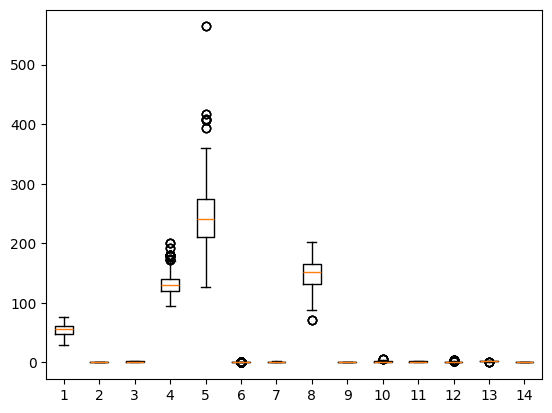

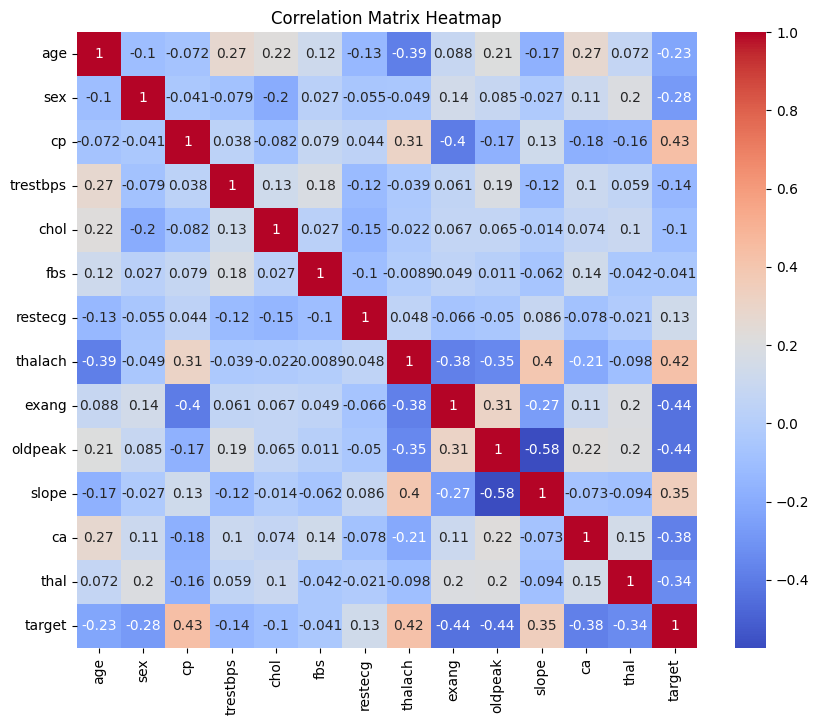

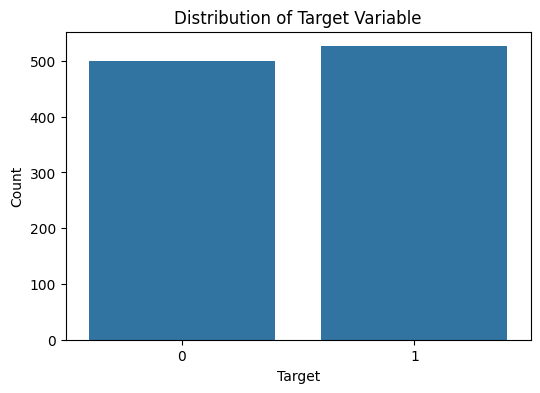

Columns dropped: ['fbs', 'restecg']


In [6]:
#Data Cleaning and Data Visualization
#Boxplot
plt.boxplot(ds)

# Heatmap for correlation
plt.figure(figsize=(10, 8))
sns.heatmap(ds.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix Heatmap")
plt.show()

# Distribution of target variable
plt.figure(figsize=(6, 4))
sns.countplot(x=ds['target'])
plt.title("Distribution of Target Variable")
plt.xlabel("Target")
plt.ylabel("Count")
plt.show()

#Based on the correlation results, we will drop colomns fbs and restecg due to their weak correlation wiith the target(Heart diseases)
columns_to_drop = ['fbs', 'restecg']
ds = ds.drop(columns=columns_to_drop, axis=1)
print(f"Columns dropped: {columns_to_drop}")

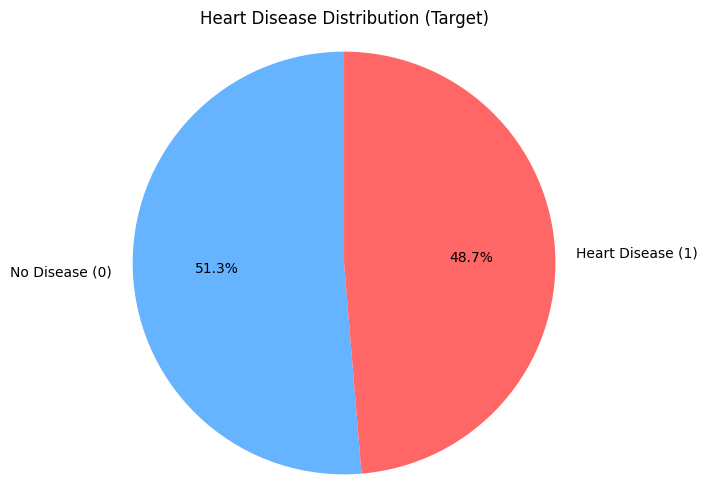

In [7]:
#Data Visualization
#Pie Chart
plt.figure(figsize=(6, 6))
target_counts = ds['target'].value_counts()
plt.pie(target_counts, labels=["No Disease (0)", "Heart Disease (1)"], autopct='%1.1f%%', startangle=90, colors=["#66b3ff", "#ff6666"])
plt.title("Heart Disease Distribution (Target)")
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()


In [8]:
#Step (4): Making the dataset available for “Supervised” Machine Learning algorithms
#Put all x variable rows into the x dataset
x = ds.drop('target', axis = 1)

#Seperate y or target variable
y = ds["target"]

In [23]:
#Step (5): Building and evaluating machine learning predictive models

#10 fold cross validation
kf = KFold(n_splits=10, shuffle= True, random_state=123)

#Decision tree model
dt_model = DecisionTreeClassifier(random_state=123)
dtaccur = cross_val_score(dt_model, x, y, cv= kf, scoring='accuracy')
print(f"Decision Tree Accuracy: {dtaccur.mean()}")

#Naïve Bayes model
nb_model = GaussianNB()
nbaccur = cross_val_score(nb_model, x, y, cv=kf, scoring='accuracy')
print(f"Naïve Bayes Accuracy: {nbaccur.mean()}")


Decision Tree Accuracy: 0.9970873786407767
Naïve Bayes Accuracy: 0.8214544070055206


In [24]:
#Step (6): Comparing the predictive models you built using Decision Tree and Naïve Bayes
def metrics(model, x, y):
    y_true = y
    y_pred = model.predict(x)
    f1_scores = cross_val_score(model, x, y, cv=kf, scoring='f1_weighted')
    print(f"\n{model.__class__.__name__} Metrics:")
    print(f"Accuracy: {accuracy_score(y_true, y_pred)}")
    print(f"Precision:\n{precision_score(y_true, y_pred, average=None)}")  # Precision for each class
    print(f"Recall:\n{recall_score(y_true, y_pred, average=None)}")  # Recall for each class


#Fittting and Metrics
dt_model.fit(x, y)
metrics(dt_model, x, y)

# Example of fitting and printing metrics for Naïve Bayes
nb_model.fit(x, y)
metrics(nb_model, x, y)


DecisionTreeClassifier Metrics:
Accuracy: 1.0
Precision:
[1. 1.]
Recall:
[1. 1.]

GaussianNB Metrics:
Accuracy: 0.824390243902439
Precision:
[0.84301075 0.80892857]
Recall:
[0.78557114 0.86121673]
